# SQL Consultas (BigQuery) para Audi A3 Alemania

**Rol de canalización:** Cuaderno obligatorio 03, validación del almacén BigQuery y paso de exploración SQL.

Este cuaderno ejecuta consultas de ejemplo SQL de solo lectura en el conjunto de datos BigQuery y produce gráficos simples para la discusión en clase. También confirma que los activos y objetos de almacén SQL esperados están disponibles antes del modelado.

**Consume:** tablas y vistas BigQuery creadas a partir de los archivos SQL ordenados.
**Produce:** gráficos y resultados de consultas mostrados; no escribe tablas de almacén.
**Feeds:** comprensión de los estudiantes del contrato de almacén antes de la regresión del Cuaderno 04 y la clasificación del Cuaderno 05.

Estas son consultas de ejemplo para discusión en el aula. No escriben tablas, pero se basan en el mismo esquema y nombres de objetos utilizados por los cuadernos posteriores.

### Descripción general funcional
Entradas: tablas BigQuery en el conjunto de datos de exploración automática.
Proceso: ejecute consultas SQL de solo lectura con uniones, filtros y agregaciones.
Salidas: tablas y gráficos mostrados que ayudan a explicar el conjunto de datos.
Motivo: estos ejemplos enseñan a los estudiantes cómo explorar los datos almacenados en BigQuery.

**Objetivo:** Demostrar consultas SQL de solo lectura para explorar el conjunto de datos.
**Entradas:** Tablas BigQuery en el conjunto de datos de exploración automática.
**Proceso:** Ejecute uniones, filtros, agregaciones y visualizaciones simples.
**Resultados:** Tablas y gráficos mostrados para discusión en el aula.
**Por qué:** SQL la exploración enseña cómo se conectan las tablas modeladas.


## 1. Importaciones y configuración

Mantenemos la configuración junta para que los estudiantes puedan cambiar el proyecto o el conjunto de datos en un solo lugar.

### Configuración
Configuramos el proyecto y el conjunto de datos una vez y luego los reutilizamos en cada consulta. Esto mantiene las consultas consistentes y fáciles de actualizar para diferentes entornos.

### Propósito de la configuración
Definimos el proyecto y el conjunto de datos una vez, lo que reduce los errores y mantiene SQL consistente.

**Objetivo:** Establecer la configuración y el cliente global BigQuery.
**Entradas:** ID de proyecto y conjunto de datos.
**Proceso:** Inicializar un cliente BigQuery.
**Salidas:** Un objeto de cliente utilizado por todas las consultas.
**Por qué:** La configuración central evita repetir ID en cada celda.


In [4]:
# Objetivo: Importar bibliotecas y definir la configuración BigQuery.  #Objetivo
# Entrada: cliente bigquery para ejecución SQL, pandas para tablas, matplotlib para gráficos.  #Aporte
# Entrada: project_config.yaml compartido para los valores predeterminados de proyecto, conjunto de datos y alcance.  #Aporte
# Proceso: importar bibliotecas, cargar la configuración, establecer ID y crear un cliente BigQuery.  #Proceso
# Salida: cliente conectado a BigQuery y variables de configuración reutilizables.  #Producción

from pathlib import Path
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / '.git').exists() or (p / 'config' / 'project_config.yaml').exists():
            return p
    return start


def load_project_config(config_path: Path) -> dict:
    config = {}
    if not config_path.exists():
        return config
    for raw_line in config_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or ':' not in line:
            continue
        key, value = line.split(':', 1)
        key = key.strip()
        value = value.strip()
        if value.startswith(('"', "'")) and value.endswith(('"', "'")):
            value = value[1:-1]
        elif value.lower() in ('true', 'false'):
            value = value.lower() == 'true'
        else:
            try:
                value = int(value)
            except ValueError:
                try:
                    value = float(value)
                except ValueError:
                    pass
        config[key] = value
    return config


REPO_ROOT = find_repo_root(Path.cwd())
PROJECT_CONFIG = load_project_config(REPO_ROOT / 'config' / 'project_config.yaml')

project_id = str(PROJECT_CONFIG.get('gcp_project_id', 'albertheadofdata101')).strip()
dataset_id = str(PROJECT_CONFIG.get('bq_dataset', 'autoscout_audi_a3_germany')).strip()
make = str(PROJECT_CONFIG.get('make', 'audi')).strip().lower()
model = str(PROJECT_CONFIG.get('model', 'a3')).strip().lower()
country_name = str(PROJECT_CONFIG.get('country', 'germany')).strip().lower()

client = bigquery.Client(project=project_id)


## 2. Ayudante para ejecutar SQL

El asistente reduce el código repetido y mantiene corta cada celda de consulta.

### Función auxiliar
El asistente run_query mantiene cortas todas las celdas de consulta al ocultar la ejecución del trabajo y la conversión del DataFrame.

### Propósito del ayudante
La función auxiliar elimina el texto repetitivo y hace que cada celda SQL sea fácil de leer.

**Objetivo:** Crear un asistente para ejecutar SQL y devolver DataFrames.
**Entradas:** SQL cadenas de consulta.
**Proceso:** Ejecutar consulta y descargar resultados.
**Salidas:** pandas DataFrames para visualización y trazado.
**Por qué:** Reduce el texto repetitivo y mantiene cortas las celdas de consulta.


In [5]:
# Objetivo: definir un asistente para ejecutar SQL y devolver un DataFrame.  #Objetivo
# Entrada: cadena SQL pasada a la función.  #Aporte
# Proceso: envíe la consulta a BigQuery y descargue los resultados como pandas.  #Proceso
# Salida: DataFrame que contiene los resultados de la consulta.  #Producción

def run_query(sql):  # Defina un asistente que tome una cadena SQL.
    query_job = client.query(sql)  # Envíe la consulta SQL a BigQuery.
    return query_job.to_dataframe()  # Descargue los resultados como un DataFrame de pandas.


## 3. Vista previa de activos y conjuntos de datos SQL


In [6]:
# Objetivo: validar el orden de activos SQL y obtener una vista previa de la vista del conjunto de datos de regresión.  #Objetivo
# Entrada: archivos SQL en sql/ y alcance del proyecto/conjunto de datos configurado.  #Aporte
# Proceso: enumere los archivos SQL requeridos, verifique su existencia y luego consulte vw_regression_dataset.  #Proceso
# Salida: Impresión de validación de activos y tabla de vista previa df_q1.  #Producción

sql_dir = REPO_ROOT / 'sql'
ordered_sql_files = [
    '00_create_dataset.sql',
    '01_create_staging.sql',
    '02_build_dimensions.sql',
    '03_build_fact.sql',
    '04_vw_regression_dataset.sql',
    '05_vw_classification_dataset.sql',
    '06_vw_bi_dashboard.sql',
]

for file_name in ordered_sql_files:
    file_path = sql_dir / file_name
    status = 'OK' if file_path.exists() else 'MISSING'
    print(f'{status}: {file_name}')

sql_query_1 = f'''
SELECT
  listing_id,
  make,
  model,
  listing_country,
  actual_price_eur,
  mileage_km,
  age_years,
  power_hp
FROM `{project_id}.{dataset_id}.vw_regression_dataset`
WHERE LOWER(make) = '{make}'
  AND LOWER(model) = '{model}'
  AND LOWER(listing_country) = '{country_name}'
LIMIT 20
'''

df_q1 = run_query(sql_query_1)
df_q1


OK: 00_create_dataset.sql
OK: 01_create_staging.sql
OK: 02_build_dimensions.sql
OK: 03_build_fact.sql
OK: 04_vw_regression_dataset.sql
OK: 05_vw_classification_dataset.sql
OK: 06_vw_bi_dashboard.sql


c:\Users\julio\Documents\DemoCode\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,listing_id,make,model,listing_country,actual_price_eur,mileage_km,age_years,power_hp
0,50,audi,a3,germany,15990,91000,11.0,150.0
1,80,audi,a3,germany,27750,50000,3.0,150.0
2,119,audi,a3,germany,10990,228000,7.0,110.0
3,152,audi,a3,germany,6800,263915,14.0,170.0
4,214,audi,a3,germany,13990,74872,10.0,110.0
5,316,audi,a3,germany,22900,98500,6.0,184.0
6,339,audi,a3,germany,23890,87518,3.0,116.0
7,391,audi,a3,germany,25970,65000,2.0,116.0
8,419,audi,a3,germany,27574,68930,3.0,150.0
9,458,audi,a3,germany,29990,49078,2.0,150.0


## 4. Consulta filtrada (país + combustible)

Esta consulta muestra cómo aplicar filtros utilizando etiquetas legibles de dimensiones.

### Ejemplo de filtrado
Filtramos por país y tipo de combustible para mostrar cómo funcionan las cláusulas WHERE con los atributos de dimensión.

### Propósito de la consulta
Esta consulta muestra cómo filtrar por país y tipo de combustible utilizando cláusulas WHERE.

**Objetivo:** Mostrar filtrado mediante atributos de dimensión.
**Entradas:** Filtrar valores por país y tipo de combustible.
**Proceso:** Aplicar cláusulas WHERE en SQL.
**Salidas:** Muestra de listado filtrado.
**Por qué:** Demuestra cómo crear subconjuntos de datos en BigQuery.


In [7]:
# Objetivo: Ejecutar una consulta filtrada por país y tipo de combustible.  #Objetivo
# Entrada: filter_country y filter_fuel controlan la cláusula WHERE.  #Aporte
# Proceso: construir SQL con filtros, ejecutar y mostrar resultados.  #Proceso
# Salida: df_q2 que contiene filas de listado filtrado.  #Producción

filter_country = country_name
filter_fuel = 'diesel'

sql_query_2 = f'''
SELECT
  dm.make AS make,
  dm.model AS model,
  df.fuel_type AS fuel_type,
  dc.listing_country AS listing_country,
  dpl.price_label AS price_label,
  fl.price_eur AS price_eur,
  fl.power_hp AS power_hp
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_fuel` AS df
  ON fl.fuel_id = df.fuel_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
WHERE dc.listing_country = '{filter_country}'
  AND df.fuel_type = '{filter_fuel}'
LIMIT 20
'''

df_q2 = run_query(sql_query_2)
df_q2


c:\Users\julio\Documents\DemoCode\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,make,model,fuel_type,listing_country,price_label,price_eur,power_hp
0,audi,a3,diesel,germany,fair-price,6800,170.0
1,audi,a3,diesel,germany,fair-price,13990,110.0
2,audi,a3,diesel,germany,fair-price,22900,184.0
3,audi,a3,diesel,germany,fair-price,23890,116.0
4,audi,a3,diesel,germany,fair-price,25970,116.0
5,audi,a3,diesel,germany,fair-price,27574,150.0
6,audi,a3,diesel,germany,fair-price,29990,150.0
7,audi,a3,diesel,germany,good-price,4900,105.0
8,audi,a3,diesel,germany,good-price,8900,110.0
9,audi,a3,diesel,germany,good-price,16700,150.0


## 5. Precios máximos para un solo modelo

Esta consulta se centra en un único modelo para ilustrar el orden y los límites.

### Ejemplo de pedido
Ordenamos por precio para encontrar los listados más caros para un modelo.

### Propósito de la consulta
Esta consulta encuentra los listados más caros para un modelo ordenando por precio.

**Objetivo:** Recuperar listados de mayor precio para un modelo.
**Entradas:** Nombre del modelo de destino.
**Proceso:** Ordenar por precio descendente y limitar resultados.
**Resultados:** Los 10 listados más caros.
**Por qué:** Muestra el orden y la clasificación en SQL.


In [8]:
# Objetivo: enumerar los 10 precios principales para el alcance del modelo configurado.  #Objetivo
# Entrada: el modelo de project_config.yaml determina qué modelo se analiza.  #Aporte
# Proceso: Construya SQL, ordene por precio descendente, límite a 10. # Proceso
# Salida: df_q3 con los listados más caros del modelo.  #Producción

target_model = model

sql_query_3 = f'''
SELECT
  dm.make AS make,
  dm.model AS model,
  dpl.price_label AS price_label,
  fl.price_eur AS price_eur,
  fl.mileage_km AS mileage_km,
  fl.power_hp AS power_hp,
  df.fuel_type AS fuel_type,
  dc.listing_country AS listing_country
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_fuel` AS df
  ON fl.fuel_id = df.fuel_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
WHERE dm.model = '{target_model}'
ORDER BY fl.price_eur DESC
LIMIT 10
'''

df_q3 = run_query(sql_query_3)
df_q3


c:\Users\julio\Documents\DemoCode\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,make,model,price_label,price_eur,mileage_km,power_hp,fuel_type,listing_country
0,audi,a3,unknown,50790,15000,150.0,diesel,germany
1,audi,a3,unknown,49890,4444,150.0,diesel,germany
2,audi,a3,unknown,47150,1,150.0,petrol,germany
3,audi,a3,unknown,46990,5500,150.0,petrol,germany
4,audi,a3,unknown,46930,3000,150.0,petrol,germany
5,audi,a3,unknown,45990,15,150.0,2,germany
6,audi,a3,unknown,45980,3090,150.0,petrol,germany
7,audi,a3,somewhat-expensive,45840,19990,190.0,petrol,germany
8,audi,a3,fair-price,44890,16363,200.0,diesel,germany
9,audi,a3,somewhat-expensive,43999,12999,150.0,diesel,germany


## 6. El listado cuenta por modelo y etiqueta de precio

Contar por etiqueta es una forma sencilla de comprobar la distribución entre categorías de precios.

### Ejemplo de agregación
Contamos los listados por modelo y etiqueta de precio para ver la distribución entre categorías.

### Propósito de la consulta
Esta consulta cuenta los listados por modelo y etiqueta de precio para mostrar la distribución.

**Objetivo:** Contar listados por modelo y etiqueta de precio.
**Entradas:** fact_listings y dimensión de la etiqueta de precio.
**Proceso:** Agrupar y contar.
**Salidas:** Recuentos de listados por grupo.
**Por qué:** Las agregaciones resumen los patrones de distribución.


In [9]:
# Objetivo: Contar listados por modelo y etiqueta de precio.  #Objetivo
# Entrada: tablas de hechos y dimensiones en BigQuery.  #Aporte
# Proceso: agrupar por modelo y etiqueta de precio, contar filas, ordenar por recuento.  #Proceso
# Salida: df_q4 con recuentos por modelo y etiqueta de precio.  #Producción

sql_query_4 = f'''  # Start SQL query string for counts.
SELECT
  dm.model AS model,
  dpl.price_label AS price_label,
  COUNT(*) AS total_listings
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
GROUP BY dm.model, dpl.price_label
ORDER BY total_listings DESC
'''  # Fin de la cadena de consulta SQL.

df_q4 = run_query(sql_query_4)  # Ejecutar consulta de agregación.
df_q4.head(10)  # Muestra las 10 filas superiores.


c:\Users\julio\Documents\DemoCode\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,model,price_label,total_listings
0,a3,fair-price,1110
1,a3,top-price,841
2,a3,good-price,804
3,a3,unknown,280
4,a3,somewhat-expensive,275
5,a3,toolow-price,54
6,a3,expensive,17


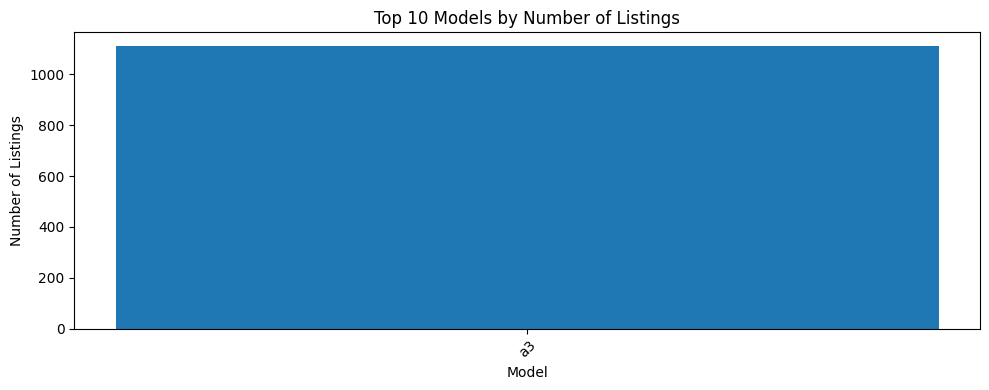

In [10]:
# Objetivo: visualizar los 10 modelos principales por recuento de listados.  #Objetivo
# Entrada: df_q4 de la consulta de agregación anterior.  #Aporte
# Proceso: seleccione las 10 filas principales y trace un gráfico de barras.  #Proceso
# Salida: un gráfico de barras que muestra los modelos más comunes.  #Producción

# Trazar los 10 modelos principales por número de listados # Utilice la salida de agregación.
top10_models = df_q4.head(10)  # Toma los 10 mejores modelos por conteo.

plt.figure(figsize=(10, 4))  # Crea una figura con un tamaño fijo.
plt.bar(top10_models['model'], top10_models['total_listings'])  # Trama cuenta por modelo.
plt.title('Top 10 Models by Number of Listings')  # Establezca el título del gráfico.
plt.xlabel('Model')  # Rotula el eje x.
plt.ylabel('Number of Listings')  # Rotula el eje y.
plt.xticks(rotation=45)  # Gire las etiquetas para facilitar la lectura.
plt.tight_layout()  # Ajuste el diseño para evitar superposiciones.
plt.show()  # Muestra la trama.


## 7. El listado cuenta por modelo, país y etiqueta de precio

Agregar el país muestra cómo varían las distribuciones entre los mercados.

### Agrupación por más dimensiones
Agregar país muestra cómo cambian los conteos en los mercados.

### Propósito de la consulta
Esta consulta agrega un país a la agrupación para que podamos comparar mercados.

**Objetivo:** Contar listados por modelo, país y etiqueta.
**Entradas:** fact_listings y dimensiones de país/etiqueta.
**Proceso:** Agrupar por múltiples dimensiones y contar.
**Salidas:** Tabla de recuentos multidimensionales.
**Por qué:** Destaca las diferencias entre mercados.


In [11]:
# Objetivo: contar listados por modelo, país y etiqueta de precio.  #Objetivo
# Entrada: tablas de hechos y dimensiones en BigQuery.  #Aporte
# Proceso: Agrupar por modelo, país, etiqueta de precio; contar y ordenar.  #Proceso
# Salida: df_q5 con recuentos por modelo/país/etiqueta.  #Producción

sql_query_5 = f'''  # Start SQL query string for multi-dimension counts.
SELECT
  dm.model AS model,
  dc.listing_country AS listing_country,
  dpl.price_label AS price_label,
  COUNT(*) AS total_listings
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
JOIN `{project_id}.{dataset_id}.dim_price_label` AS dpl
  ON fl.price_label_id = dpl.price_label_id
GROUP BY dm.model, dc.listing_country, dpl.price_label
ORDER BY dm.model ASC, total_listings DESC
'''  # Fin de la cadena de consulta SQL.

df_q5 = run_query(sql_query_5)  # Ejecute la consulta agrupada.
df_q5.head(20)  # Mostrar una muestra de filas.


c:\Users\julio\Documents\DemoCode\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,model,listing_country,price_label,total_listings
0,a3,germany,fair-price,1110
1,a3,germany,top-price,841
2,a3,germany,good-price,804
3,a3,germany,unknown,280
4,a3,germany,somewhat-expensive,275
5,a3,germany,toolow-price,54
6,a3,germany,expensive,17


## 8. Precio medio y potencia por modelo y país

Las métricas agregadas son útiles para realizar comparaciones y obtener información rápida.

### Métricas promedio
Los promedios ofrecen una visión compacta de las diferencias de precio y potencia entre países.

### Propósito de la consulta
Esta consulta calcula el precio y la potencia promedio por modelo y país para realizar comparaciones.

**Objetivo:** Calcular precio y potencia promedio por modelo y país.
**Entradas:** fact_listings con campos numéricos.
**Proceso:** Resultados promedio y redondos.
**Salidas:** Tabla de precio medio y potencia.
**Por qué:** Los agregados proporcionan comparaciones rápidas por clase.


In [12]:
# Objetivo: Calcular precio y potencia promedio por modelo y país.  #Objetivo
# Entrada: tablas de hechos y dimensiones en BigQuery.  #Aporte
# Proceso: Agrupar por modelo/país, calcular promedios, ordenar por precio promedio.  #Proceso
# Salida: df_q6 con precio medio y potencia por grupo.  #Producción

sql_query_6 = f'''  # Start SQL query string for averages.
SELECT
  dm.model AS model,
  dc.listing_country AS listing_country,
  ROUND(AVG(fl.price_eur), 2) AS avg_price_eur,
  ROUND(AVG(fl.power_hp), 2) AS avg_power_hp
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
JOIN `{project_id}.{dataset_id}.dim_country` AS dc
  ON fl.country_id = dc.country_id
GROUP BY dm.model, dc.listing_country
ORDER BY avg_price_eur DESC
'''  # Fin de la cadena de consulta SQL.

df_q6 = run_query(sql_query_6)  # Ejecutar consulta promedio.
df_q6.head(20)  # Muestra las filas superiores.


c:\Users\julio\Documents\DemoCode\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,model,listing_country,avg_price_eur,avg_power_hp
0,a3,germany,21455.82,139.08


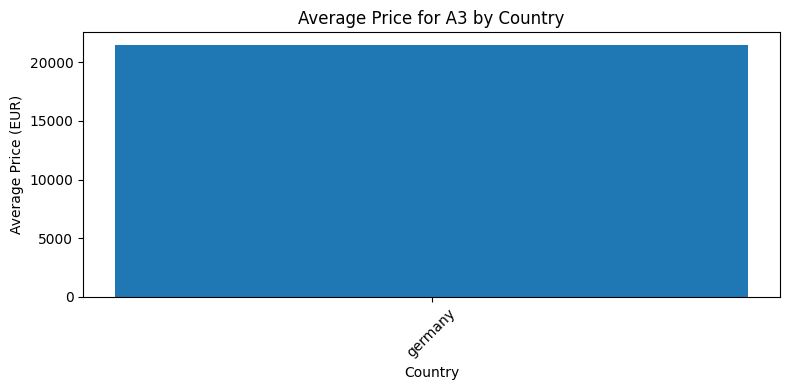

In [13]:
# Objetivo: Trazar el precio medio por país para un solo modelo.  #Objetivo
# Entrada: df_q6 que contiene promedios por modelo y país.  #Aporte
# Proceso: filtrar por un modelo, crear un gráfico de barras de precios promedio.  #Proceso
# Salida: Un gráfico de barras que compara los precios promedio entre países.  #Producción

# Visualice el precio promedio de un solo modelo en todos los países. # Utilice resultados agregados.
model_for_plot = 'a3'  # Elija el modelo a visualizar.

df_model = df_q6[df_q6['model'] == model_for_plot]  # Filtrar a un modelo.

plt.figure(figsize=(8, 4))  # Crea una figura con un tamaño fijo.
plt.bar(df_model['listing_country'], df_model['avg_price_eur'])  # Precio medio de la parcela por país.
plt.title(f'Average Price for {model_for_plot.upper()} by Country')  # Título con nombre del modelo.
plt.xlabel('Country')  # Rotula el eje x.
plt.ylabel('Average Price (EUR)')  # Rotula el eje y.
plt.xticks(rotation=45)  # Gire las etiquetas para facilitar la lectura.
plt.tight_layout()  # Ajuste el diseño para evitar superposiciones.
plt.show()  # Muestra la trama.
